## Imports

In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.constants import EMOTION_LABELS, NUM_CLASSES
from src.dataset import FER2013Dataset
from src.train_utils import set_seed, get_device

## Configuration

In [2]:
CSV_PATH = PROJECT_ROOT / "data/raw/fer2013/fer2013.csv"

WANDB_ENTITY = "lkhiz23-free-university-of-tbilisi-"
WANDB_PROJECT = "facial-expression-recognition"

ENABLE_WANDB = True

TRAIN_MEAN = 0.5077426
TRAIN_STD = 0.25500894

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

RESNET_IMAGE_SIZE = 224

IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

device = get_device()

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## ResNet18 Input Preprocessing

In [3]:
def build_resnet_augmentation(augmentation):
    if augmentation == "none":
        return None

    if augmentation == "hflip":
        return transforms.RandomHorizontalFlip(
            p=0.5,
        )

    if augmentation == "light":
        return transforms.Compose([
            transforms.RandomHorizontalFlip(
                p=0.5,
            ),
            transforms.RandomAffine(
                degrees=10,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
            ),
        ])

    raise ValueError(
        f"Unknown augmentation: {augmentation}"
    )

In [4]:
class ResNetFER2013Dataset(Dataset):
    def __init__(
        self,
        csv_path,
        split,
        augmentation="none",
    ):
        self.base_dataset = FER2013Dataset(
            csv_path,
            split=split,
            transform=None,
        )

        self.augmentation = build_resnet_augmentation(
            augmentation
        )

        self.resize = transforms.Resize(
            (RESNET_IMAGE_SIZE, RESNET_IMAGE_SIZE),
            antialias=True,
        )

        self.imagenet_normalize = transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        image, label = self.base_dataset[index]

        # Undo FER2013 train mean/std normalization.
        image = image * TRAIN_STD + TRAIN_MEAN
        image = image.clamp(0.0, 1.0)

        if self.augmentation is not None:
            image = self.augmentation(image)

        image = self.resize(image)

        # Convert grayscale image from 1 channel to 3 channels.
        image = image.repeat(3, 1, 1)

        image = self.imagenet_normalize(image)

        return image, label

## Dataset Sanity Check

In [5]:
train_dataset = ResNetFER2013Dataset(
    CSV_PATH,
    split="Training",
    augmentation="none",
)

val_dataset = ResNetFER2013Dataset(
    CSV_PATH,
    split="PublicTest",
    augmentation="none",
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

image, label = train_dataset[0]

print("ResNet image shape:", image.shape)
print("Label:", label.item())
print("Image minimum:", image.min().item())
print("Image maximum:", image.max().item())

Train samples: 28709
Validation samples: 3589
ResNet image shape: torch.Size([3, 224, 224])
Label: 0
Image minimum: -1.9111835956573486
Image maximum: 1.8351447582244873


## ResNet18 Architecture

In [6]:
def build_resnet18_model(
    fine_tune_strategy,
    dropout,
):
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    classifier_input_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(
            classifier_input_features,
            NUM_CLASSES,
        ),
    )

    # Freeze everything first.
    for parameter in model.parameters():
        parameter.requires_grad = False

    if fine_tune_strategy == "frozen":
        # Train only the new classifier.
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif fine_tune_strategy == "layer4":
        # Train the final residual block and classifier.
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif fine_tune_strategy == "full":
        # Fine-tune the whole pretrained network.
        for parameter in model.parameters():
            parameter.requires_grad = True

    else:
        raise ValueError(
            "Unknown fine-tune strategy: "
            f"{fine_tune_strategy}"
        )

    return model

In [7]:
def count_model_parameters(model):
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return total_parameters, trainable_parameters

## Model Sanity Check

პირველივე გამოყენებისას PyTorch pretrained ResNet18 weights-ს ავტომატურად ჩამოტვირთავს.

შემდეგ გაშვებებზე იგივე weights local cache-დან ჩაიტვირთება.

In [8]:
set_seed(42)

model = build_resnet18_model(
    fine_tune_strategy="layer4",
    dropout=0.3,
).to(device)

total_parameters, trainable_parameters = (
    count_model_parameters(model)
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

sample_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

sample_images, sample_labels = next(
    iter(sample_loader)
)

sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

outputs = model(sample_images)

criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, sample_labels)

model.zero_grad()
loss.backward()

print("Input shape:", sample_images.shape)
print("Output shape:", outputs.shape)
print("Loss:", loss.item())
print("Backward pass: OK")

Total parameters: 11180103
Trainable parameters: 8397319
Input shape: torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 7])
Loss: 1.7227916717529297
Backward pass: OK


## Batch Normalization Handling

In [9]:
def configure_model_training_mode(
    model,
    fine_tune_strategy,
):
    model.train()

    if fine_tune_strategy == "frozen":
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

    elif fine_tune_strategy == "layer4":
        for name, module in model.named_modules():
            if (
                isinstance(module, nn.BatchNorm2d)
                and not name.startswith("layer4")
            ):
                module.eval()

## Metrics

In [10]:
def calculate_metrics(labels, predictions):
    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }

## Training and Evaluation Functions

In [11]:
def train_resnet_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    fine_tune_strategy,
):
    configure_model_training_mode(
        model,
        fine_tune_strategy,
    )

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.detach().cpu().tolist()
        )

        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

    average_loss = total_loss / len(loader.dataset)

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )

    return average_loss, metrics

In [12]:
@torch.no_grad()
def evaluate_resnet(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().tolist()
        )

        all_predictions.extend(
            predictions.cpu().tolist()
        )

    average_loss = total_loss / len(loader.dataset)

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )

    return (
        average_loss,
        metrics,
        all_labels,
        all_predictions,
    )

## Helper: small subset

In [13]:
def make_small_subset(
    dataset,
    size=50,
    seed=42,
):
    random_generator = np.random.default_rng(
        seed
    )

    indices = random_generator.choice(
        len(dataset),
        size=size,
        replace=False,
    )

    return Subset(
        dataset,
        indices.tolist(),
    )

## Optimizer

In [14]:
def build_resnet_optimizer(
    model,
    run_config,
):
    fine_tune_strategy = (
        run_config["fine_tune_strategy"]
    )

    head_learning_rate = (
        run_config["head_learning_rate"]
    )

    backbone_learning_rate = (
        run_config["backbone_learning_rate"]
    )

    weight_decay = run_config["weight_decay"]

    if fine_tune_strategy == "frozen":
        parameter_groups = [
            {
                "params": model.fc.parameters(),
                "lr": head_learning_rate,
                "name": "head",
            }
        ]

    elif fine_tune_strategy == "layer4":
        parameter_groups = [
            {
                "params": model.layer4.parameters(),
                "lr": backbone_learning_rate,
                "name": "backbone",
            },
            {
                "params": model.fc.parameters(),
                "lr": head_learning_rate,
                "name": "head",
            },
        ]

    elif fine_tune_strategy == "full":
        backbone_parameters = [
            parameter
            for name, parameter
            in model.named_parameters()
            if not name.startswith("fc.")
        ]

        parameter_groups = [
            {
                "params": backbone_parameters,
                "lr": backbone_learning_rate,
                "name": "backbone",
            },
            {
                "params": model.fc.parameters(),
                "lr": head_learning_rate,
                "name": "head",
            },
        ]

    else:
        raise ValueError(
            "Unknown fine-tune strategy: "
            f"{fine_tune_strategy}"
        )

    return torch.optim.Adam(
        parameter_groups,
        weight_decay=weight_decay,
    )

In [15]:
def build_resnet_scheduler(
    optimizer,
    run_config,
):
    scheduler_name = run_config["scheduler"]

    if scheduler_name == "none":
        return None

    if scheduler_name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
        )

    raise ValueError(
        f"Unknown scheduler: {scheduler_name}"
    )

## Helper: plot history

In [16]:
def plot_resnet_history(
    history_df,
    run_name,
    sanity_check=False,
):
    plt.figure(figsize=(8, 4))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="Train Loss",
    )

    if sanity_check:
        plt.plot(
            history_df["epoch"],
            history_df["small_data_loss"],
            label="Small Data Loss",
        )
    else:
        plt.plot(
            history_df["epoch"],
            history_df["val_loss"],
            label="Validation Loss",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{run_name} Loss")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        IMAGES_DIR / f"{run_name}_loss.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    plt.figure(figsize=(8, 4))

    plt.plot(
        history_df["epoch"],
        history_df["train_accuracy"],
        label="Train Accuracy",
    )

    if sanity_check:
        plt.plot(
            history_df["epoch"],
            history_df["small_data_accuracy"],
            label="Small Data Accuracy",
        )
    else:
        plt.plot(
            history_df["epoch"],
            history_df["val_accuracy"],
            label="Validation Accuracy",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{run_name} Accuracy")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        IMAGES_DIR / f"{run_name}_accuracy.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

## Run One ResNet18 Experiment

In [17]:
def run_resnet18_experiment(run_config):
    set_seed(run_config["seed"])

    run_name = run_config["run_name"]
    sanity_check = run_config["sanity_check"]

    current_train_dataset = ResNetFER2013Dataset(
        CSV_PATH,
        split="Training",
        augmentation=run_config["augmentation"],
    )

    current_val_dataset = ResNetFER2013Dataset(
        CSV_PATH,
        split="PublicTest",
        augmentation="none",
    )

    if sanity_check:
        small_dataset = make_small_subset(
            current_train_dataset,
            size=run_config["small_data_size"],
            seed=run_config["seed"],
        )

        train_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    else:
        train_loader = DataLoader(
            current_train_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            current_val_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    model = build_resnet18_model(
        fine_tune_strategy=(
            run_config["fine_tune_strategy"]
        ),
        dropout=run_config["dropout"],
    ).to(device)

    (
        total_parameters,
        trainable_parameters,
    ) = count_model_parameters(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = build_resnet_optimizer(
        model,
        run_config,
    )

    scheduler = build_resnet_scheduler(
        optimizer,
        run_config,
    )

    logged_config = dict(run_config)
    logged_config["total_parameters"] = (
        total_parameters
    )
    logged_config["trainable_parameters"] = (
        trainable_parameters
    )
    logged_config["device"] = str(device)

    run = None

    if ENABLE_WANDB:
        run = wandb.init(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            name=run_name,
            config=logged_config,
        )

    history = []

    best_small_data_accuracy = 0.0

    best_val_accuracy = 0.0
    best_val_epoch = 0
    best_state_dict = None
    best_checkpoint_macro_f1 = 0.0

    early_stopping_patience = run_config.get(
        "early_stopping_patience"
    )

    epochs_without_improvement = 0

    for epoch in range(
        1,
        run_config["epochs"] + 1,
    ):
        train_loss, train_metrics = (
            train_resnet_one_epoch(
                model,
                train_loader,
                optimizer,
                criterion,
                device,
                run_config["fine_tune_strategy"],
            )
        )

        (
            eval_loss,
            eval_metrics,
            eval_labels,
            eval_predictions,
        ) = evaluate_resnet(
            model,
            eval_loader,
            criterion,
            device,
        )

        if scheduler is not None:
            scheduler.step(eval_loss)

        learning_rates = {
            group.get("name", f"group_{index}"):
                group["lr"]
            for index, group
            in enumerate(optimizer.param_groups)
        }

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy":
                train_metrics["accuracy"],
            "train_macro_f1":
                train_metrics["macro_f1"],
            "head_learning_rate":
                learning_rates.get("head"),
            "backbone_learning_rate":
                learning_rates.get("backbone"),
        }

        if sanity_check:
            best_small_data_accuracy = max(
                best_small_data_accuracy,
                eval_metrics["accuracy"],
            )

            row.update({
                "small_data_loss": eval_loss,
                "small_data_accuracy":
                    eval_metrics["accuracy"],
                "small_data_macro_f1":
                    eval_metrics["macro_f1"],
                "best_small_data_accuracy":
                    best_small_data_accuracy,
            })

            print(
                f"{run_name} | "
                f"Epoch {epoch:02d}/"
                f"{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc="
                f"{train_metrics['accuracy']:.4f} | "
                f"small_loss={eval_loss:.4f} "
                f"small_acc="
                f"{eval_metrics['accuracy']:.4f}",
                flush=True,
            )

        else:
            if (
                eval_metrics["accuracy"]
                > best_val_accuracy
            ):
                best_val_accuracy = (
                    eval_metrics["accuracy"]
                )

                best_checkpoint_macro_f1 = (
                    eval_metrics["macro_f1"]
                )

                best_val_epoch = epoch

                best_state_dict = deepcopy(
                    model.state_dict()
                )

                epochs_without_improvement = 0

            else:
                epochs_without_improvement += 1

            row.update({
                "val_loss": eval_loss,
                "val_accuracy":
                    eval_metrics["accuracy"],
                "val_macro_f1":
                    eval_metrics["macro_f1"],
                "best_val_accuracy":
                    best_val_accuracy,
                "best_checkpoint_macro_f1":
                    best_checkpoint_macro_f1,
                "best_val_epoch":
                    best_val_epoch,
            })

            print(
                f"{run_name} | "
                f"Epoch {epoch:02d}/"
                f"{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc="
                f"{train_metrics['accuracy']:.4f} | "
                f"val_loss={eval_loss:.4f} "
                f"val_acc="
                f"{eval_metrics['accuracy']:.4f} "
                f"val_f1="
                f"{eval_metrics['macro_f1']:.4f}",
                flush=True,
            )

        history.append(row)

        if ENABLE_WANDB:
            wandb.log(
                row,
                step=epoch,
            )

        if (
            sanity_check
            and best_small_data_accuracy >= 0.999
        ):
            print(
                "Small-data memorization passed."
            )
            break

        if (
            not sanity_check
            and early_stopping_patience is not None
            and epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best validation accuracy: "
                f"{best_val_accuracy:.5f} "
                f"at epoch {best_val_epoch}."
            )
            break

    history_df = pd.DataFrame(history)

    plot_resnet_history(
        history_df,
        run_name,
        sanity_check=sanity_check,
    )

    if (
        not sanity_check
        and best_state_dict is not None
    ):
        model.load_state_dict(best_state_dict)

        (
            best_checkpoint_loss,
            best_checkpoint_metrics,
            best_labels,
            best_predictions,
        ) = evaluate_resnet(
            model,
            eval_loader,
            criterion,
            device,
        )

        checkpoint_path = (
            CHECKPOINTS_DIR
            / f"{run_name}_best.pt"
        )

        torch.save(
            best_state_dict,
            checkpoint_path,
        )

        if ENABLE_WANDB:
            class_names = [
                EMOTION_LABELS[index]
                for index in range(NUM_CLASSES)
            ]

            wandb.log({
                "best_validation_confusion_matrix":
                    wandb.plot.confusion_matrix(
                        y_true=best_labels,
                        preds=best_predictions,
                        class_names=class_names,
                    )
            })

            run.summary["best_val_accuracy"] = (
                best_val_accuracy
            )

            run.summary[
                "best_checkpoint_val_macro_f1"
            ] = best_checkpoint_metrics["macro_f1"]

            run.summary["best_val_epoch"] = (
                best_val_epoch
            )

            run.summary[
                "best_checkpoint_val_loss"
            ] = best_checkpoint_loss

    if ENABLE_WANDB:
        if sanity_check:
            run.summary[
                "best_small_data_accuracy"
            ] = best_small_data_accuracy

        run.summary["epochs_trained"] = len(history)
        run.summary["total_parameters"] = (
            total_parameters
        )
        run.summary["trainable_parameters"] = (
            trainable_parameters
        )

        run.finish()

    if sanity_check:
        result = {
            "run_name": run_name,
            "fine_tune_strategy":
                run_config["fine_tune_strategy"],
            "trainable_parameters":
                trainable_parameters,
            "best_small_data_accuracy":
                best_small_data_accuracy,
            "epochs_trained": len(history),
        }

    else:
        result = {
            "run_name": run_name,
            "fine_tune_strategy":
                run_config["fine_tune_strategy"],
            "augmentation":
                run_config["augmentation"],
            "dropout": run_config["dropout"],
            "weight_decay":
                run_config["weight_decay"],
            "head_learning_rate":
                run_config["head_learning_rate"],
            "backbone_learning_rate":
                run_config["backbone_learning_rate"],
            "scheduler":
                run_config["scheduler"],
            "epochs_planned":
                run_config["epochs"],
            "epochs_trained": len(history),
            "total_parameters":
                total_parameters,
            "trainable_parameters":
                trainable_parameters,
            "best_val_epoch":
                best_val_epoch,
            "best_val_accuracy":
                best_val_accuracy,
            "best_checkpoint_val_macro_f1":
                best_checkpoint_macro_f1,
        }

    return result, history_df

## ResNet18 Run Configurations

In [18]:
BASE_CONFIG = {
    "dataset": "FER2013",
    "model_name": "resnet18",
    "architecture_type": "transfer_learning",
    "pretrained_weights": "ImageNet1K",
    "input_shape": "3x224x224",
    "seed": 42,
    "train_split": "Training",
    "val_split": "PublicTest",
}

In [19]:
RESNET18_RUNS = [
    {
        **BASE_CONFIG,
        "run_name":
            "run_21_resnet18_small50_overfit",
        "experiment_type":
            "small_data_overfit_sanity_check",
        "sanity_check": True,
        "small_data_size": 50,
        "fine_tune_strategy": "full",
        "augmentation": "none",
        "dropout": 0.0,
        "backbone_learning_rate": 1e-4,
        "head_learning_rate": 1e-3,
        "weight_decay": 0.0,
        "scheduler": "none",
        "batch_size": 10,
        "epochs": 40,
        "early_stopping_patience": None,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_22_resnet18_frozen_backbone",
        "experiment_type":
            "frozen_feature_extractor",
        "sanity_check": False,
        "small_data_size": None,
        "fine_tune_strategy": "frozen",
        "augmentation": "none",
        "dropout": 0.3,
        "backbone_learning_rate": None,
        "head_learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "none",
        "batch_size": 16,
        "epochs": 8,
        "early_stopping_patience": 4,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_23_resnet18_layer4_finetune",
        "experiment_type":
            "partial_fine_tuning",
        "sanity_check": False,
        "small_data_size": None,
        "fine_tune_strategy": "layer4",
        "augmentation": "hflip",
        "dropout": 0.3,
        "backbone_learning_rate": 1e-4,
        "head_learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "none",
        "batch_size": 16,
        "epochs": 12,
        "early_stopping_patience": 5,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_24_resnet18_full_finetune",
        "experiment_type":
            "full_fine_tuning",
        "sanity_check": False,
        "small_data_size": None,
        "fine_tune_strategy": "full",
        "augmentation": "hflip",
        "dropout": 0.3,
        "backbone_learning_rate": 1e-5,
        "head_learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "scheduler": "none",
        "batch_size": 16,
        "epochs": 15,
        "early_stopping_patience": 6,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_25_resnet18_full_aug_scheduler",
        "experiment_type":
            "full_fine_tuning_scheduler",
        "sanity_check": False,
        "small_data_size": None,
        "fine_tune_strategy": "full",
        "augmentation": "light",
        "dropout": 0.3,
        "backbone_learning_rate": 3e-5,
        "head_learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "scheduler": "plateau",
        "batch_size": 16,
        "epochs": 20,
        "early_stopping_patience": 6,
    },
]

## Choose Run Mode

In [20]:
RUN_MODE = "full"
# "sanity", "full", or "all"

if RUN_MODE == "sanity":
    SELECTED_RUNS = [RESNET18_RUNS[0]]

elif RUN_MODE == "full":
    SELECTED_RUNS = RESNET18_RUNS[1:]

elif RUN_MODE == "all":
    SELECTED_RUNS = RESNET18_RUNS

else:
    raise ValueError(
        f"Unknown RUN_MODE: {RUN_MODE}"
    )

print("Selected runs:")

for run_config in SELECTED_RUNS:
    print("-", run_config["run_name"])

Selected runs:
- run_22_resnet18_frozen_backbone
- run_23_resnet18_layer4_finetune
- run_24_resnet18_full_finetune
- run_25_resnet18_full_aug_scheduler


## Run Selected ResNet18 Experiments

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


run_22_resnet18_frozen_backbone | Epoch 01/8 | train_loss=1.6047 train_acc=0.3808 | val_loss=1.4700 val_acc=0.4319 val_f1=0.3510
run_22_resnet18_frozen_backbone | Epoch 02/8 | train_loss=1.5292 train_acc=0.4150 | val_loss=1.4344 val_acc=0.4673 val_f1=0.3852
run_22_resnet18_frozen_backbone | Epoch 03/8 | train_loss=1.5288 train_acc=0.4215 | val_loss=1.4616 val_acc=0.4397 val_f1=0.3458
run_22_resnet18_frozen_backbone | Epoch 04/8 | train_loss=1.5270 train_acc=0.4205 | val_loss=1.4492 val_acc=0.4472 val_f1=0.3445
run_22_resnet18_frozen_backbone | Epoch 05/8 | train_loss=1.5256 train_acc=0.4219 | val_loss=1.4609 val_acc=0.4531 val_f1=0.3872
run_22_resnet18_frozen_backbone | Epoch 06/8 | train_loss=1.5251 train_acc=0.4233 | val_loss=1.4256 val_acc=0.4689 val_f1=0.3772
run_22_resnet18_frozen_backbone | Epoch 07/8 | train_loss=1.5238 train_acc=0.4244 | val_loss=1.4395 val_acc=0.4689 val_f1=0.3949
run_22_resnet18_frozen_backbone | Epoch 08/8 | train_loss=1.5204 train_acc=0.4202 | val_loss=1.48

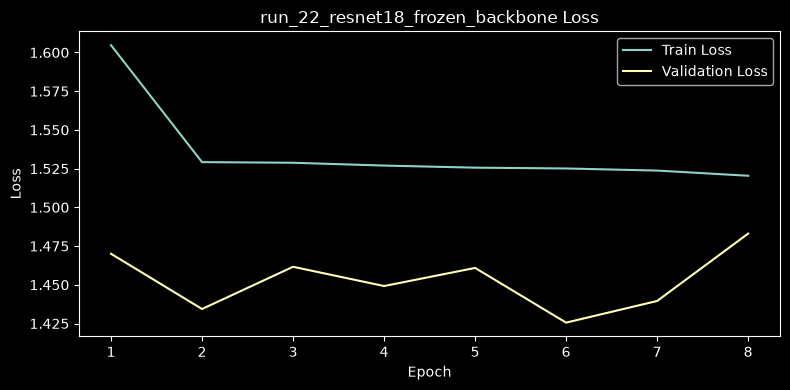

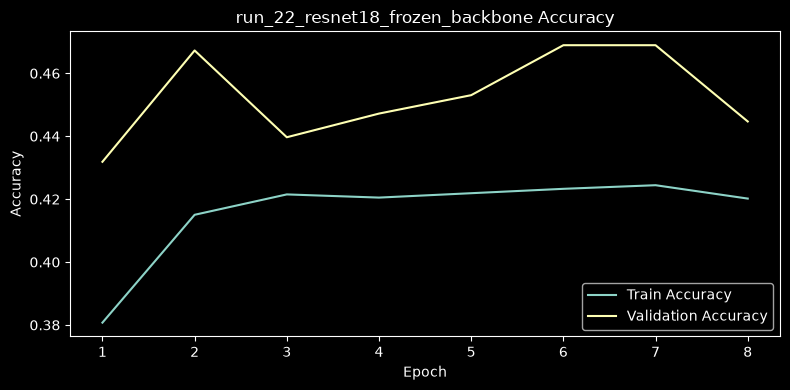

best_checkpoint_macro_f1,▁████▆▆▆
best_val_accuracy,▁███████
best_val_epoch,▁▂▂▂▂███
epoch,▁▂▃▄▅▆▇█
head_learning_rate,▁▁▁▁▁▁▁▁
train_accuracy,▁▆█▇███▇
train_loss,█▂▂▂▁▁▁▁
train_macro_f1,▁▆▇▇███▇
val_accuracy,▁█▂▄▅██▃
val_loss,▆▂▅▄▅▁▃█
+1,...


run_23_resnet18_layer4_finetune | Epoch 01/12 | train_loss=1.2275 train_acc=0.5447 | val_loss=1.0740 val_acc=0.6027 val_f1=0.5598
run_23_resnet18_layer4_finetune | Epoch 02/12 | train_loss=0.9813 train_acc=0.6396 | val_loss=0.9969 val_acc=0.6372 val_f1=0.5975
run_23_resnet18_layer4_finetune | Epoch 03/12 | train_loss=0.8335 train_acc=0.6976 | val_loss=1.0542 val_acc=0.6367 val_f1=0.5980
run_23_resnet18_layer4_finetune | Epoch 04/12 | train_loss=0.6902 train_acc=0.7543 | val_loss=1.0468 val_acc=0.6570 val_f1=0.6382
run_23_resnet18_layer4_finetune | Epoch 05/12 | train_loss=0.5417 train_acc=0.8093 | val_loss=1.1402 val_acc=0.6573 val_f1=0.6307
run_23_resnet18_layer4_finetune | Epoch 06/12 | train_loss=0.4277 train_acc=0.8512 | val_loss=1.2418 val_acc=0.6545 val_f1=0.6318
run_23_resnet18_layer4_finetune | Epoch 07/12 | train_loss=0.3453 train_acc=0.8814 | val_loss=1.3853 val_acc=0.6495 val_f1=0.6311
run_23_resnet18_layer4_finetune | Epoch 08/12 | train_loss=0.2908 train_acc=0.9031 | val_l

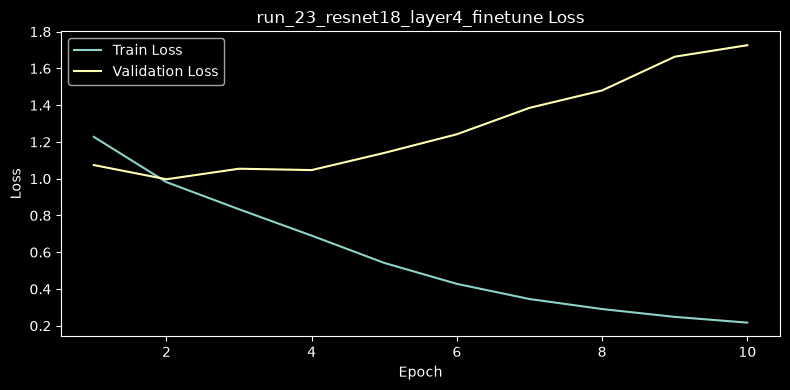

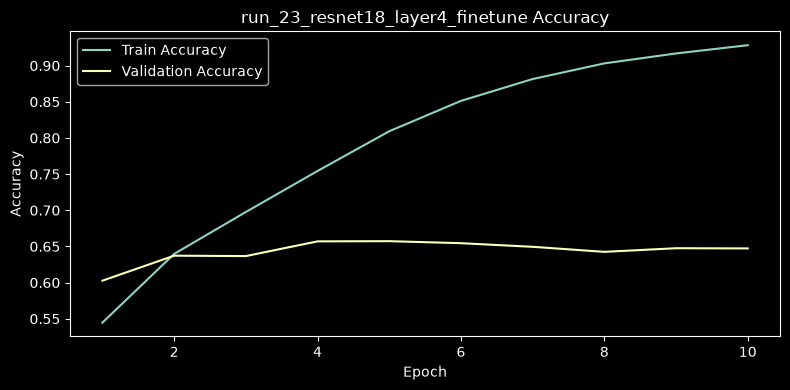

backbone_learning_rate,▁▁▁▁▁▁▁▁▁▁
best_checkpoint_macro_f1,▁▄▄█▇▇▇▇▇▇
best_val_accuracy,▁▅▅███████
best_val_epoch,▁▃▃▆██████
epoch,▁▂▃▃▄▅▆▆▇█
head_learning_rate,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▄▅▆▇▇███
train_loss,█▆▅▄▃▂▂▂▁▁
train_macro_f1,▁▃▄▅▆▇▇███
val_accuracy,▁▅▅███▇▆▇▇
+2,...


run_24_resnet18_full_finetune | Epoch 01/15 | train_loss=1.3945 train_acc=0.4667 | val_loss=1.1380 val_acc=0.5692 val_f1=0.4776
run_24_resnet18_full_finetune | Epoch 02/15 | train_loss=1.1153 train_acc=0.5828 | val_loss=1.0368 val_acc=0.6074 val_f1=0.5344
run_24_resnet18_full_finetune | Epoch 03/15 | train_loss=1.0011 train_acc=0.6277 | val_loss=1.0281 val_acc=0.6219 val_f1=0.5460
run_24_resnet18_full_finetune | Epoch 04/15 | train_loss=0.9169 train_acc=0.6618 | val_loss=0.9979 val_acc=0.6375 val_f1=0.5676
run_24_resnet18_full_finetune | Epoch 05/15 | train_loss=0.8244 train_acc=0.6945 | val_loss=0.9906 val_acc=0.6473 val_f1=0.6034
run_24_resnet18_full_finetune | Epoch 06/15 | train_loss=0.7472 train_acc=0.7269 | val_loss=1.0029 val_acc=0.6537 val_f1=0.6058
run_24_resnet18_full_finetune | Epoch 07/15 | train_loss=0.6601 train_acc=0.7619 | val_loss=1.0347 val_acc=0.6565 val_f1=0.6262
run_24_resnet18_full_finetune | Epoch 08/15 | train_loss=0.5771 train_acc=0.7958 | val_loss=1.0763 val_a

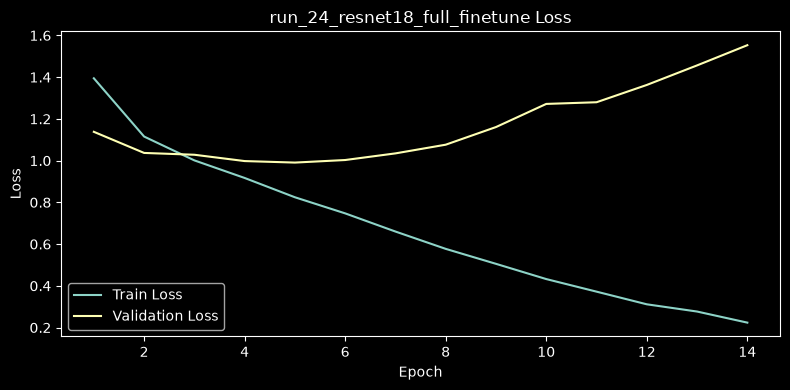

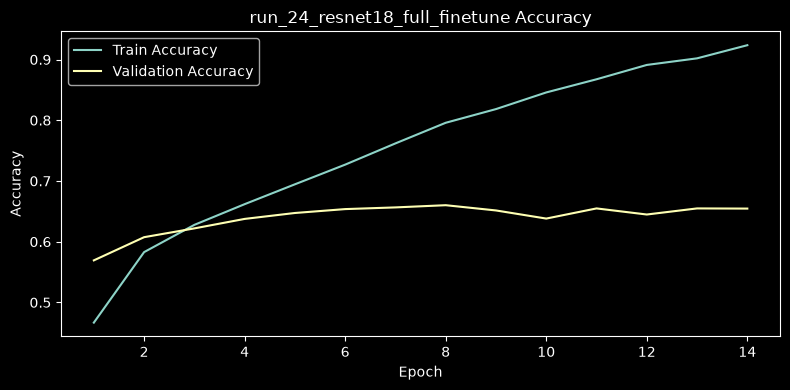

backbone_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_checkpoint_macro_f1,▁▄▄▅▇▇████████
best_val_accuracy,▁▄▅▆▇█████████
best_val_epoch,▁▂▃▄▅▆▇███████
epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
head_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▃▄▄▅▆▆▆▇▇███
train_loss,█▆▆▅▅▄▄▃▃▂▂▂▁▁
train_macro_f1,▁▃▃▄▅▅▆▆▇▇▇███
val_accuracy,▁▄▅▆▇███▇▆█▇██
+2,...


run_25_resnet18_full_aug_scheduler | Epoch 01/20 | train_loss=1.3248 train_acc=0.4973 | val_loss=1.0733 val_acc=0.5907 val_f1=0.5253
run_25_resnet18_full_aug_scheduler | Epoch 02/20 | train_loss=1.0858 train_acc=0.5926 | val_loss=1.0120 val_acc=0.6247 val_f1=0.5542
run_25_resnet18_full_aug_scheduler | Epoch 03/20 | train_loss=0.9924 train_acc=0.6307 | val_loss=0.9744 val_acc=0.6428 val_f1=0.6028
run_25_resnet18_full_aug_scheduler | Epoch 04/20 | train_loss=0.9351 train_acc=0.6509 | val_loss=0.9541 val_acc=0.6456 val_f1=0.6060
run_25_resnet18_full_aug_scheduler | Epoch 05/20 | train_loss=0.8873 train_acc=0.6680 | val_loss=0.9322 val_acc=0.6601 val_f1=0.6318
run_25_resnet18_full_aug_scheduler | Epoch 06/20 | train_loss=0.8386 train_acc=0.6909 | val_loss=0.9382 val_acc=0.6601 val_f1=0.6296
run_25_resnet18_full_aug_scheduler | Epoch 07/20 | train_loss=0.8011 train_acc=0.7064 | val_loss=0.9245 val_acc=0.6684 val_f1=0.6397
run_25_resnet18_full_aug_scheduler | Epoch 08/20 | train_loss=0.7550 

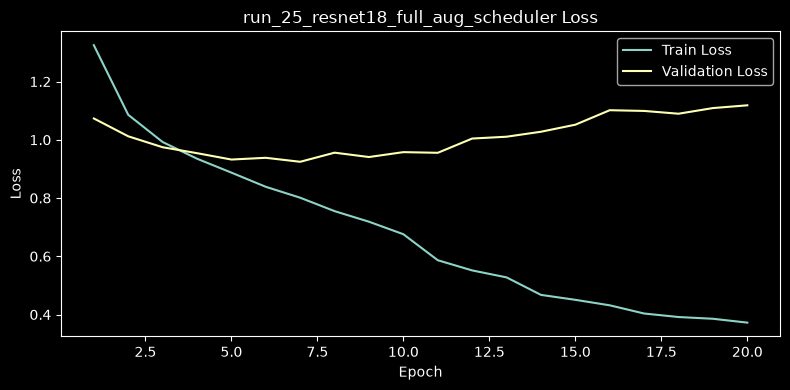

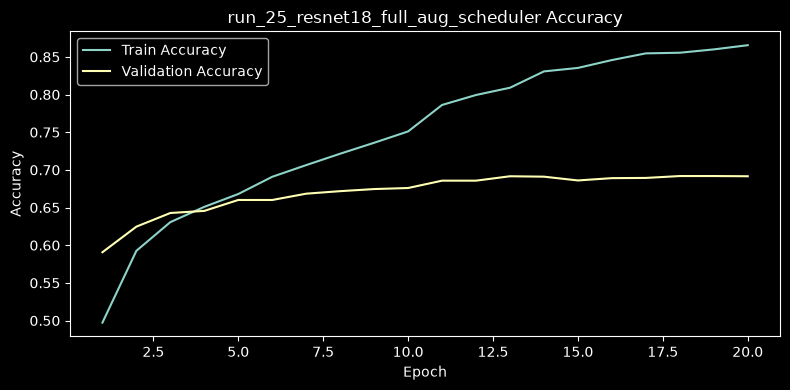

backbone_learning_rate,█████████▄▄▄▂▂▂▁▁▁▁▁
best_checkpoint_macro_f1,▁▂▄▅▆▆▆▇▇▇▇▇████████
best_val_accuracy,▁▃▅▅▆▆▆▇▇▇██████████
best_val_epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▆▆███
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
head_learning_rate,█████████▄▄▄▂▂▂▁▁▁▁▁
train_accuracy,▁▃▄▄▄▅▅▅▆▆▆▇▇▇▇█████
train_loss,█▆▆▅▅▄▄▄▄▃▃▂▂▂▂▁▁▁▁▁
train_macro_f1,▁▃▄▄▄▅▅▅▆▆▇▇▇▇██████
val_accuracy,▁▃▅▅▆▆▆▇▇▇██████████
+2,...


,run_name,fine_tune_strategy,augmentation,dropout,weight_decay,head_learning_rate,backbone_learning_rate,scheduler,epochs_planned,epochs_trained,total_parameters,trainable_parameters,best_val_epoch,best_val_accuracy,best_checkpoint_val_macro_f1
0,run_22_resnet18_frozen_backbone,frozen,none,0.3,0.0001,0.0010,NaN,none,8,8,11180103,3591,6,0.468933,0.377177
1,run_23_resnet18_layer4_finetune,layer4,hflip,0.3,0.0001,0.0010,0.00010,none,12,10,11180103,8397319,5,0.657286,0.630706
2,run_24_resnet18_full_finetune,full,hflip,0.3,0.0001,0.0003,0.00001,none,15,14,11180103,11180103,8,0.660072,0.630052
3,run_25_resnet18_full_aug_scheduler,full,light,0.3,0.0001,0.0003,0.00003,plateau,20,20,11180103,11180103,18,0.691836,0.684620


In [21]:
resnet18_results = []
resnet18_histories = {}

for run_config in SELECTED_RUNS:
    result, history_df = (
        run_resnet18_experiment(
            run_config
        )
    )

    resnet18_results.append(result)

    resnet18_histories[
        run_config["run_name"]
    ] = history_df

resnet18_results_df = pd.DataFrame(
    resnet18_results
)

resnet18_results_df

## Results

In [22]:
if (
    "best_val_accuracy"
    in resnet18_results_df.columns
):
    resnet18_results_df.sort_values(
        "best_val_accuracy",
        ascending=False,
    )
else:
    resnet18_results_df